In [1]:
from bioio import BioImage
import bioio_sldy
import time
import numpy as np
import matplotlib.pyplot as plt
import os
# Define paths

In [11]:
compressed_path = r"Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2-compressed.sldyz"
uncompressed_path = r"Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2.sldy"

# Load both files
print("Loading compressed file...")
start = time.time()
img_compressed = BioImage(compressed_path, reader=bioio_sldy.Reader)
compressed_load_time = time.time() - start
print(f"Compressed load time: {compressed_load_time:.3f}s")

print("\nLoading uncompressed file...")
start = time.time()
img_uncompressed = BioImage(uncompressed_path, reader=bioio_sldy.Reader)
uncompressed_load_time = time.time() - start
print(f"Uncompressed load time: {uncompressed_load_time:.3f}s")


Loading compressed file...
Compressed load time: 0.922s

Loading uncompressed file...
Uncompressed load time: 0.759s


In [12]:

# Compare properties
print("\n=== Comparison ===")
print(f"Compressed shape: {img_compressed.shape}")
print(f"Uncompressed shape: {img_uncompressed.shape}")
print(f"Shapes match: {img_compressed.shape == img_uncompressed.shape}")

print(f"\nCompressed scenes: {len(img_compressed.scenes)}")
print(f"Uncompressed scenes: {len(img_uncompressed.scenes)}")
print(f"Scenes match: {img_compressed.scenes == img_uncompressed.scenes}")

# Compare actual data
print("\n=== Data Comparison ===")
compressed_data = img_compressed.data
uncompressed_data = img_uncompressed.data

print(f"Data shapes match: {compressed_data.shape == uncompressed_data.shape}")
print(f"Data types match: {compressed_data.dtype == uncompressed_data.dtype}")
print(f"Data values match: {np.array_equal(compressed_data, uncompressed_data)}")

if not np.array_equal(compressed_data, uncompressed_data):
    print(f"Max difference: {np.abs(compressed_data - uncompressed_data).max()}")

print("\n=== Dimension Order ===")
print(f"Compressed: {img_compressed.dims.order} -> {img_compressed.shape}")
print(f"Uncompressed: {img_uncompressed.dims.order} -> {img_uncompressed.shape}")



=== Comparison ===
Compressed shape: (1, 3, 1, 1544, 1144)
Uncompressed shape: (1, 3, 1, 1544, 1144)
Shapes match: True

Compressed scenes: 2
Uncompressed scenes: 2
Scenes match: True

=== Data Comparison ===
Data shapes match: True
Data types match: True
Data values match: True

=== Dimension Order ===
Compressed: TCZYX -> (1, 3, 1, 1544, 1144)
Uncompressed: TCZYX -> (1, 3, 1, 1544, 1144)


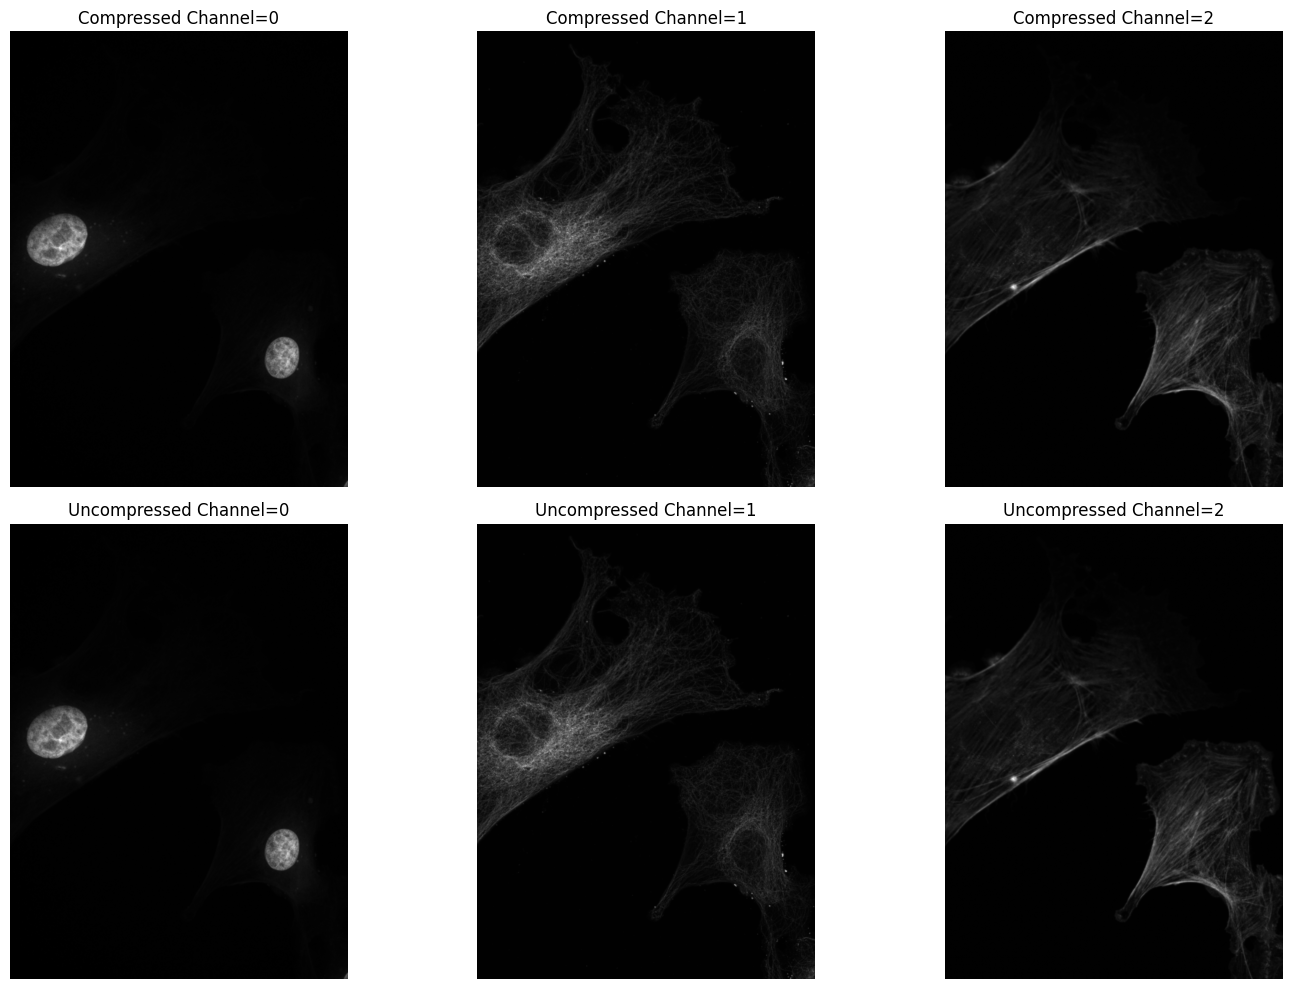

In [13]:

# Compare multiple channels since Z dimension is 1
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i in range(3):  # Iterate through 3 channels
    # Compressed channel slices
    axes[0, i].imshow(img_compressed.data[0, i, 0, :, :], cmap='gray')
    axes[0, i].set_title(f"Compressed Channel={i}")
    axes[0, i].axis('off')

    # Uncompressed channel slices
    axes[1, i].imshow(img_uncompressed.data[0, i, 0, :, :], cmap='gray')
    axes[1, i].set_title(f"Uncompressed Channel={i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [9]:
## export the compressed image to OME-TIFF with metadata

import os

filename = os.path.splitext(os.path.basename(compressed_path))[0]
base_dir = os.path.dirname(compressed_path)
output_dir = os.path.join(base_dir, filename+"_tiff")
print(f"Saving compressed image to {output_dir}")

# Create the ometiff folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

img = img_compressed

for scene_idx in range(len(img.scenes)):
    # Set the current scene
    img.set_scene(scene_idx)
    scene_name = img.current_scene
    print(f"Processing scene {scene_idx}: {scene_name}")

    # Extract metadata
    metadata = img.metadata

    # Extract pixel sizes (in micrometers)
    physical_pixel_sizes = img.physical_pixel_sizes
    lateral_pixel_size_x = physical_pixel_sizes.X  # X dimension
    lateral_pixel_size_y = physical_pixel_sizes.Y  # Y dimension
    axial_pixel_size = physical_pixel_sizes.Z  # Z dimension

    print(f"Lateral pixel size (X): {lateral_pixel_size_x} µm")
    print(f"Lateral pixel size (Y): {lateral_pixel_size_y} µm")
    print(f"Axial pixel size (Z): {axial_pixel_size} µm")

    # Extract time information from metadata if available
    if hasattr(metadata, 'time_captured'):
        print(f"Time captured: {metadata.time_captured}")
    if hasattr(metadata, 'time_interval'):
        print(f"Time interval: {metadata.time_interval}")

    # Export to OME-TIFF with metadata
    output_filename = f"scene_{scene_idx}_{scene_name}.ome.tiff"
    output_path = os.path.join(output_dir, output_filename)
    data = img.data

    # In your export loop, add channel information
    channel_names = img.channel_names
    print(f"Channels: {', '.join(channel_names)}")

    # Include channel names in OME-TIFF metadata
    tifffile.imwrite(
        output_path,
        data,
        photometric='minisblack',
        metadata={
            'axes': img.dims.order,
            'channel_names': channel_names,
            'PhysicalSizeX': lateral_pixel_size_x,
            'PhysicalSizeY': lateral_pixel_size_y,
            'PhysicalSizeZ': axial_pixel_size,
            'PhysicalSizeXUnit': 'µm',
            'PhysicalSizeYUnit': 'µm',
            'PhysicalSizeZUnit': 'µm'
        },
        description=str(metadata),
        resolution=(1/lateral_pixel_size_x, 1/lateral_pixel_size_y)
    )


    print(f"Exported {output_path}\n")


Saving compressed image to Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2-compressedometiff
Processing scene 0: AS_TreatA-1769013428-656
Lateral pixel size (X): 0.1032 µm
Lateral pixel size (Y): 0.1032 µm
Axial pixel size (Z): None µm
Channels: 0, 1, 2
Exported Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2-compressedometiff\scene_0_AS_TreatA-1769013428-656.ome.tiff

Processing scene 1: AS_TreatB-1769013429-539
Lateral pixel size (X): 0.1032 µm
Lateral pixel size (Y): 0.1032 µm
Axial pixel size (Z): None µm
Channels: 0, 1, 2
Exported Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2-compressedometiff\scene_1_AS_TreatB-1769013429-539.ome.tiff



In [9]:
print("\n=== Detailed Channel Metadata ===")
image_metadata = img_compressed.metadata
print(image_metadata)


=== Detailed Channel Metadata ===
{'annotation_record': {'CDataTableHeaderRecord70': {'ClassName': 'CDataTableHeaderRecord70', 'mByteOrdering': 18761, 'mChannelIndex': 0, 'mColumns': 1, 'mDescriptorFileOffset': 0, 'mDescriptorSize': 0, 'mDescriptorVersion': 0, 'mNextTableFileOffset': 0, 'mParentRecordPtr': 0, 'mPlanes': 1, 'mRows': 1, 'mStartTime': 0, 'mStructID': 125, 'mStructLen': 344, 'mStructVersion': 257, 'mTableType': 7, 'mTimeBasis': 6, 'mTimeInterval': 1, 'mTimePointsTableSize': 1, 'mTimePointsWritten': 0, 'mValueType': 10}, 'EndClass': 'CDataTableHeaderRecord70', 'theTimepointIndex': 0, 'theCubeAnnotation70ListSize': 0, 'theAnnotation70ListSize': 0, 'theFRAPRegionAnnotation70ListSize': 0, 'theUnknownAnnotation70ListSize': 0}, 'aux_data': {'theAuxFloatDataTablesSize': 0, 'theAuxDoubleDataTablesSize': 0, 'theAuxSInt32DataTablesSize': 0, 'theAuxSInt64DataTablesSize': 0, 'theAuxSerializedDataTablesSize': 4, 'CDataTableHeaderRecord70': [{'ClassName': 'CDataTableHeaderRecord70', 'm